# 单元3作业
    刘易昊 524021910055

首先进行一些基础设定：
- 加载常用的头文件
- 设置中文显示格式，避免乱码



In [15]:
#加载头文件
import numpy as np
import pandas as pd
import scipy.stats as stats
import statistics as sta
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
#中文显示设置
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]  


## 问题1: 置信区间 （2 points）
### （1）. 数据可视化 （0.25）

分别画出男生、女生身高的分布密度图

绘制男生、女生身高的箱体图（Box Plot）

读取数据，并对性别进行处理，让1映射为女生，2映射为男生。然后设置基础颜色格式，让女生数据的图像为粉色，男生数据的图像为天蓝，便于阅读。

这里之所这么设置主要是为了让箱型图的x轴显示性别，而不是数字1、2。

In [16]:
data1=pd.read_csv("Heights.csv")
data1

,ID,Gender,Height
0,1,2,176
1,2,2,171
2,3,1,162
3,4,1,170
4,5,1,158
5,6,2,175
6,7,1,163
7,8,1,166
8,9,2,173
9,10,1,169


In [17]:
#通用颜色风格设定
data1["Gender_Label"]=data1["Gender"].map({1: "女生", 2: "男生"})
colorset1 = {"女生": "pink", "男生": "skyblue"}

分别做出男女身高分布密度图，首先要按Gender进行分类，然后再分别作出核密度分布图。

这里我们用到 hue 参数进行分类，然后对图片进行中文标注。

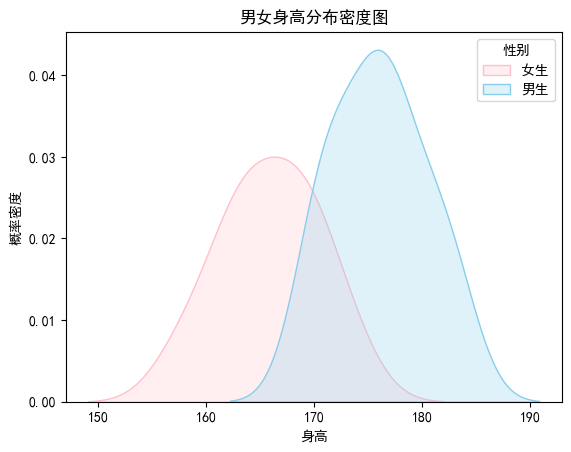

In [18]:

sns.kdeplot(data=data1, x="Height", hue="Gender_Label", palette=colorset1, fill=True)
#添加中文标注
plt.title("男女身高分布密度图")
plt.xlabel("身高")
plt.ylabel("概率密度")
plt.legend(title="性别", labels=["女生", "男生"]) 
plt.show()

然后做出箱型图，虽然x参数就能自动分类，但是这里还是需要用hue和palette参数来设置颜色。

依旧添加上中文标注，并且用颜色区分男女。

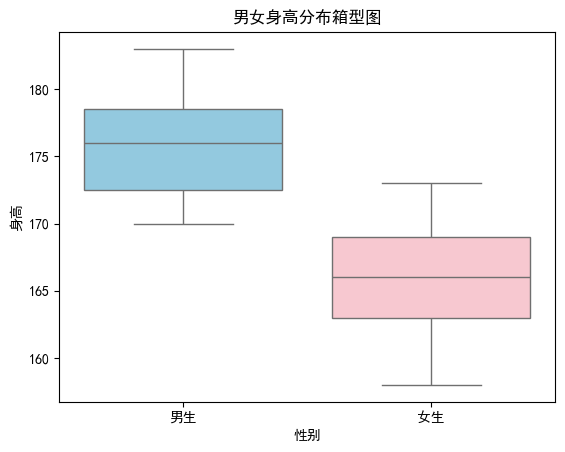

In [19]:
sns.boxplot(data=data1,x="Gender_Label",y="Height", hue="Gender_Label", palette=colorset1)
#添加中文标注
plt.title("男女身高分布箱型图")
plt.xlabel("性别")
plt.ylabel("身高")
plt.show()

### （2）. 描述统计 （0.25）

计算男生、女生身高的以下统计量：

均值（Mean）

中位数（Median）

方差（Variance）

标准差（Standard Deviation）

峰度（Kurtosis）

偏度（Skewness）

由于要分组对男生女生两组数据求以上的几个统计量，这里我们可以用groupby()函数进行分类，再用agg()函数进行对以上统计量的计算。

首先采用groupby函数的一下形式：data.groupby["A", "B"]，根据选定的这一列A，把数据分成两组，然后再按照列B分类。

然后是agg()函数，首先对常见的统计量，我们用中文重命名。然后是在运行程序时候，发现直接使用 ` ("峰度", "kurtosis")  ` 会产生报错，查询ai得到以下回复：

> 这个 AttributeError 报错的原因非常直接：在 Pandas 的 groupby 聚合操作中，字符串名称 "kurtosis" 并不是一个被所有版本直接支持的合法别名。我建议你使用 lambda 函数，因为它可以直接调用对象方法，避开这种别名不一致的问题。

所以在计算峰度的时候先定义一个临时匿名函数，接受参数x，然后调用x.kurt()，返回计算结果。



In [20]:
desc_stats = data1.groupby("Gender_Label")["Height"].agg([
    ("均值", "mean"),
    ("中位数", "median"),
    ("方差", "var"),
    ("标准差", "std"),
    ("偏度", "skew"),
    ("峰度", lambda x: x.kurt())
])

display(desc_stats)

,均值,中位数,方差,标准差,偏度,峰度
Gender_Label,,,,,,
女生,165.888889,166.0,21.361111,4.621808,-0.182361,-0.379756
男生,176.000000,176.0,18.363636,4.285281,0.191306,-0.950257


### （3）. 正态性判断 （0.25）

根据上面的可视化结果和描述统计量，判断男生、女生身高分布的正态性

说明判断依据（结合密度图、偏度、峰度等指标）

- 1.从密度图来看，男女两组数据都是单峰，且无明显左偏/右偏，很符合正态分布的形态。

- 2.男女身高的均值和中位数几乎一致，女生的偏度小于零轻微左拖，男生的偏度大于零轻微右拖，但是偏度的绝对值均小于0.2，说明对称性很好。

- 3.男女身高的峰度均为负数，说明与标准正态分布相比，实际分布略显平坦，但是绝对值均小于1，可以认为近似正态分布。

### （4）. 置信区间计算 （1.25）

分别计算男生、女生身高的95%置信区间

计算男生与女生身高差的95%置信区间

计算男生与女生身高差异的95%置信区间

说明使用了哪种方法（独立样本的哪种情况）以及原因

首先，把男女身高的数据分开

In [21]:
fheight = data1[data1["Gender_Label"] == "女生"]["Height"]
mheight = data1[data1["Gender_Label"] == "男生"]["Height"]

In [22]:
fheight

2     162
3     170
4     158
6     163
7     166
9     169
11    173
14    164
17    168
Name: Height, dtype: int64

In [23]:
mheight

0     176
1     171
5     175
8     173
10    180
12    176
13    178
15    182
16    170
18    183
19    171
20    177
Name: Height, dtype: int64

- 1.对于男女身高分别的的样本均值的置信区间，我们只知道样本的 $\bar{x}$ 和 $s$，所以构造单样本的t分布。已知 $\alpha=0.05$，$CI=\bar{x}\pm t_{\alpha/2,df}\cdot \frac{s}{\sqrt{n}}$，$df=n-1$。


先定义t分布置信区间的求解函数

In [24]:
def mean_ci_t(data,ci):
    n=len(data)
    #这里求解标准差，自由度-1
    std=np.std(data,ddof=1)
    m=np.mean(data)
    sem=std/np.sqrt(n)
    moe=stats.t.isf((1-ci)/2,n-1)*sem
    return m-moe,m+moe

生成女生身高的95%置信区间

In [25]:
f_l,f_h=mean_ci_t(fheight,0.95)   
print("女生身高的95%置信区间是: [{:.2f}, {:.2f}]".format(f_l,f_h))

女生身高的95%置信区间是: [162.34, 169.44]


生成男生身高的95%置信区间

In [26]:
m_l,m_h=mean_ci_t(mheight,0.95)   
print("男生身高的95%置信区间是: [{:.2f}, {:.2f}]".format(m_l,m_h))

男生身高的95%置信区间是: [173.28, 178.72]


- 2.计算男生与女生身高差的95%置信区间，

本题中的两个样本是总体标准差不等且未知的情况，我们构造T统计量：
$$
T = \frac{(\bar{X}_1 - \bar{X}_2) - (\mu_1 - \mu_2)}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}} \sim t(df)
$$

用Welch-Satterthwaite 自由度公式来计算自由度：
$$
df=\frac{\left( \frac{s_1^2}{n_1}+\frac{s_2^2}{n_2} \right) ^2}{\frac{1}{n_1-1}\left(\frac{s_1^2}{n_1}\right)^2
+\frac{1}{n_2-1}\left(\frac{s_2^2}{n_2}\right)^2}
$$

根据以上的数学关系，我们来定义计算两个样本平均值差异的函数

In [27]:
def double_mean_ci_t(data1, data2, ci):
    n1=len(data1)
    n2=len(data2)
    #这里求解标准差，自由度-1
    std1=np.std(data1,ddof=1)
    std2=np.std(data2,ddof=1)
    m1=np.mean(data1)
    m2=np.mean(data2)
    m=m1-m2
    var1=std1**2/n1
    var2=std2**2/n2
    sem=np.sqrt(var1+var2)
    df=(var1+var2)**2/(var1**2/(n1-1)+var2**2/(n2-1))
    moe=stats.t.isf((1-ci)/2,df)*sem
    return m-moe,m+moe

In [28]:
l,h=double_mean_ci_t(fheight, mheight, 0.95)
print("男生与女生身高差异的95%置信区间是: [{:.2f}, {:.2f}]".format(l,h))

男生与女生身高差异的95%置信区间是: [-14.29, -5.94]


## 问题2: NHST（2 points）
研究人员想探讨两种饮食方式（低碳饮食 vs. 低脂饮食）对糖尿病患者空腹血糖水平的影响。研究对象为50名糖尿病患者，随机分成两组，一组接受低碳饮食（LC），另一组接受低脂饮食（LF），分别观察两组患者在干预6周后的空腹血糖水平（mmol/L）。
- Patient_ID：患者编号
- Diet_Group：饮食类型（LC 或 LF）
- Fasting_Blood_Sugar：干预后的空腹血糖水平（mmol/L）

首先读取数据

In [29]:
data2=pd.read_csv("blood_sugar.csv")
data2

,Patient_ID,Diet_Group,Fasting_Blood_Sugar
0,1,LF,5.953284
1,2,LC,5.871856
2,3,LF,7.053302
3,4,LC,5.286566
4,5,LC,5.750724
5,6,LF,6.017230
6,7,LF,6.524543
7,8,LC,5.657256
8,9,LC,6.185931
9,10,LF,5.742655


### 1.数据可视化 （0.5）

- 画出两组血糖水平的箱线图，并计算均值、标准差。


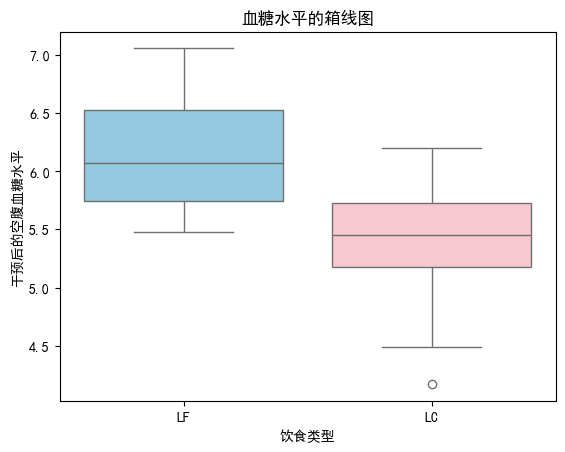

In [30]:
#先设置一下颜色
colorset2 = {"LC": "pink", "LF": "skyblue"}
#开始绘图
sns.boxplot(data=data2, x="Diet_Group", y="Fasting_Blood_Sugar", hue="Diet_Group", palette=colorset2)
#添加中文标注
plt.xlabel("饮食类型")
plt.ylabel("干预后的空腹血糖水平")
plt.title("血糖水平的箱线图")
plt.show()

分别计算均值和标准差

In [31]:
desc_stats = data2.groupby("Diet_Group")["Fasting_Blood_Sugar"].agg([
    ("均值", "mean"),
    ("标准差", "std"),
])

display(desc_stats)

,均值,标准差
Diet_Group,,
LC,5.439599,0.495907
LF,6.157176,0.513907


- 使用直方图和密度曲线比较两组血糖水平的分布形态。

为了绘制直方图，我们先把LC和LF组的数据分开：

In [32]:
lc = data2[data2["Diet_Group"] == "LC"]["Fasting_Blood_Sugar"]
lf = data2[data2["Diet_Group"] == "LF"]["Fasting_Blood_Sugar"]

display(lc)
display(lf)

1     5.871856
3     5.286566
4     5.750724
7     5.657256
8     6.185931
12    5.371685
13    5.316087
14    6.136867
15    5.354024
16    4.172412
17    5.672759
19    5.355432
20    5.726468
21    5.416970
23    4.488843
24    5.028472
26    5.490725
27    4.663248
28    4.963734
29    5.003707
30    5.551174
34    5.738877
35    5.370486
36    5.212645
38    5.669910
39    5.496310
41    4.925104
45    6.192008
46    6.202603
47    6.196163
48    5.059680
49    5.538447
Name: Fasting_Blood_Sugar, dtype: float64

0     5.953284
2     7.053302
5     6.017230
6     6.524543
9     5.742655
10    6.510274
11    6.119531
18    6.881943
22    5.479979
25    5.766427
31    5.591573
32    6.724674
33    6.862553
37    5.634786
40    6.412243
42    5.766179
43    6.272931
44    5.515064
Name: Fasting_Blood_Sugar, dtype: float64

然后分别对两种饮食类型绘制直方图

<Axes: title={'center': '饮食类型：LF'}, xlabel='干预后的空腹血糖水平（mmol/L）', ylabel='数量'>

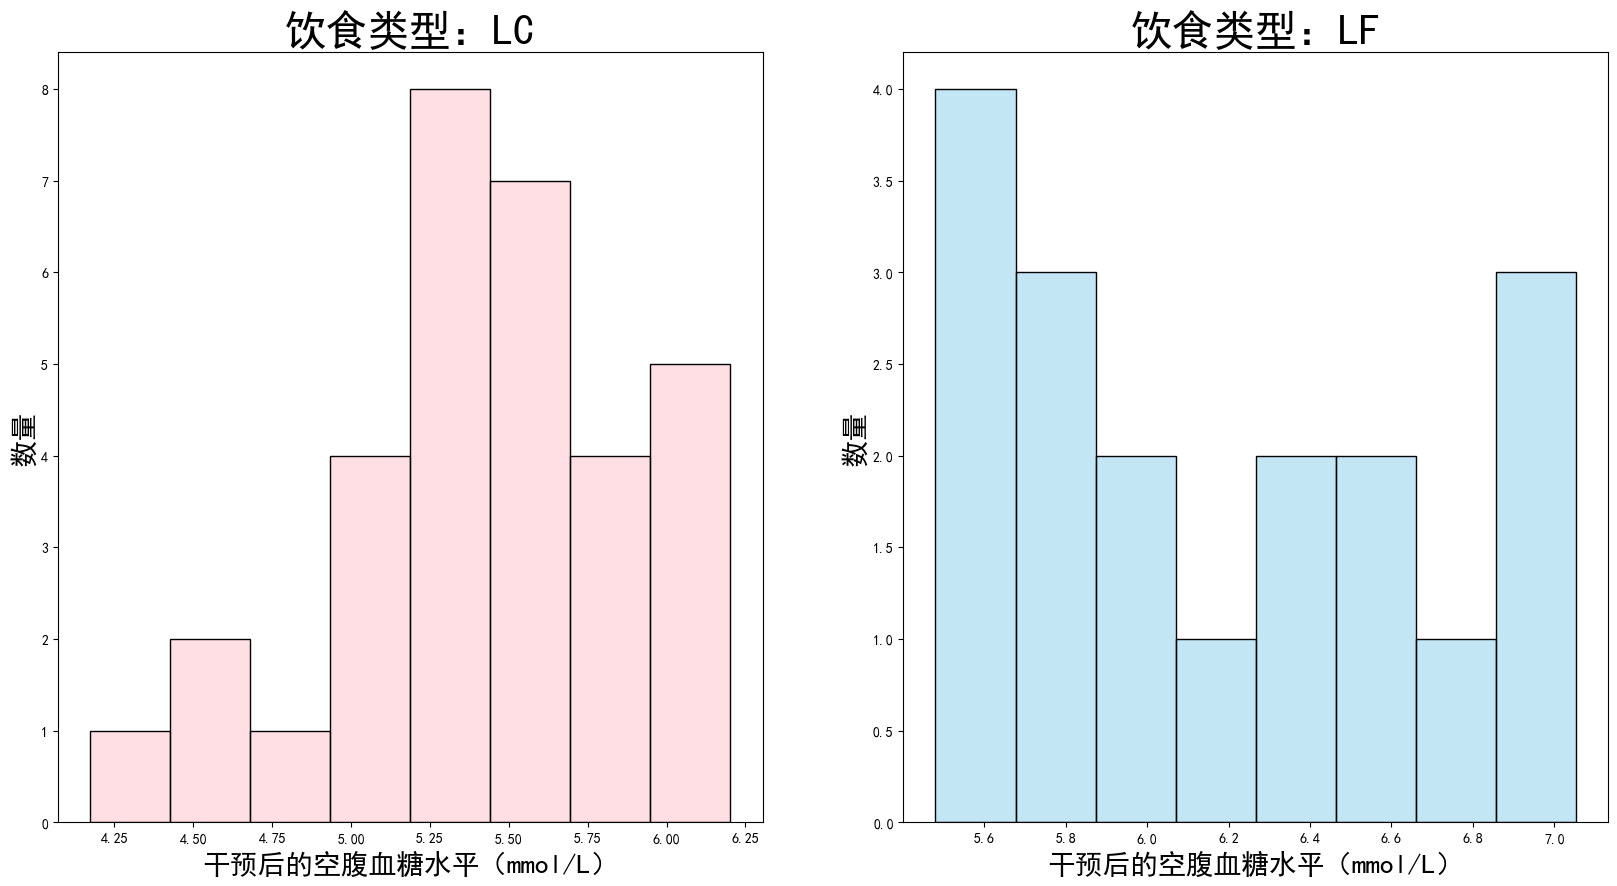

In [33]:
fig,ax=plt.subplots(1,2,figsize=(20,10))
ax[0].set_xlabel("干预后的空腹血糖水平（mmol/L）", fontsize=20)
ax[0].set_ylabel("数量", fontsize=20)
ax[0].set_title("饮食类型：LC", fontsize=30)
sns.histplot(data=lc, bins=8,  ax=ax[0], color="pink", alpha=0.5)
ax[1].set_xlabel("干预后的空腹血糖水平（mmol/L）", fontsize=20)
ax[1].set_ylabel("数量", fontsize=20)
ax[1].set_title("饮食类型：LF", fontsize=30)
sns.histplot(data=lf, bins=8,  ax=ax[1], color="skyblue", alpha=0.5)


然后绘制密度曲线，为了方便比较我们直接绘制在一张图上：

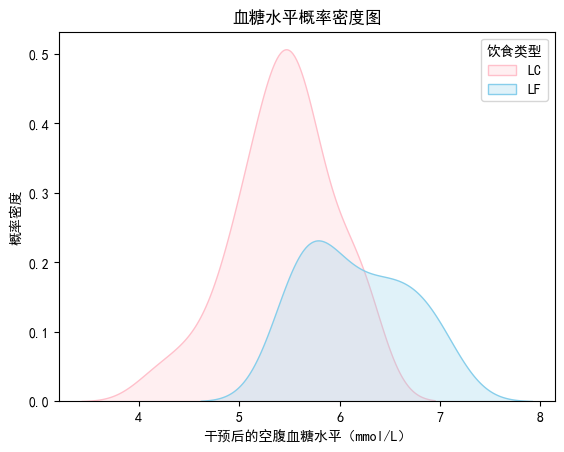

In [34]:
sns.kdeplot(data=data2, x="Fasting_Blood_Sugar", hue="Diet_Group", palette=colorset2, fill=True)
#添加中文标注
plt.title("血糖水平概率密度图")
plt.xlabel("干预后的空腹血糖水平（mmol/L）")
plt.ylabel("概率密度")
plt.legend(title="饮食类型", labels=["LC", "LF"]) 
plt.show()

比较分布形态：
- 1.从中心位置来看：在直方图中，LC组的峰值集中在 5.25 mmol/L附近，整体分布偏右；LF组峰值在 5.6mmol/L 附近。而在密度图中，可以看到LC组分布向左拖尾，LF组分布向右拖尾。
- 2.从集中趋势来看：LC组明显更集中，而LF组没有明显的单峰集中区，更加分散。
- 3.整体分布：可以看到LF组干预后的血糖水平明显高于LC组。

### 计算题：（1.5）

- 计算每组的95%置信区间，并解释其意义。

我们只知道样本的平均值和方差，所以采用t-检验，可以利用上一题定义过的函数。


In [35]:
l,h=mean_ci_t(lc,0.95)   
print("LC组血糖的95%置信区间是: [{:.2f}, {:.2f}]".format(l,h))

LC组血糖的95%置信区间是: [5.26, 5.62]


In [36]:
l,h=mean_ci_t(lf,0.95)   
print("LF组血糖的95%置信区间是: [{:.2f}, {:.2f}]".format(l,h))

LF组血糖的95%置信区间是: [5.90, 6.41]


- 计算两组均值差异的95%置信区间，并判断该区间是否包含0。

95%置信区间的含义是：我们有95%的信心，LC/LF组的总体平均空腹血糖落在该区间内。

总体标准差不等且未知，我们构造T统计量，可以利用上一题定义过的函数。

In [37]:
l,h=double_mean_ci_t(lc, lf, 0.95)
print("两组均值差异的95%置信区间是: [{:.2f}, {:.2f}]".format(l,h))

两组均值差异的95%置信区间是: [-1.02, -0.41]


可以看到两组均值差异的95%置信区间是: [-1.02, -0.41]，b不包含0，表示在0.05显著性水平下，两组血糖的均值差异有统计显著性。

- 假设总体分布为正态，使用独立样本t检验检验零假设：
    * H₀：两种饮食方式的血糖控制效果没有显著差异（即均值相等）。
    * H₁：两种饮食方式的血糖控制效果有显著差异。
    
    选择适当的显著性水平（如α=0.05），计算p值，并判断是否拒绝零假设。


首先确定假设：$H_0: \mu_1-\mu_2=0$，$H_1: \mu_1-\mu_2 \neq 0$
然后构建统计量，由于两个总体的方差都未知，与上一小问中的情形类似，所以我们选择t检验：
$$
T = \frac{(\bar{X}_1 - \bar{X}_2) - (\mu_1 - \mu_2)}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}} \sim t(df)
$$

用Welch-Satterthwaite 自由度公式来计算自由度：
$$
df=\frac{\left( \frac{s_1^2}{n_1}+\frac{s_2^2}{n_2} \right) ^2}{\frac{1}{n_1-1}\left(\frac{s_1^2}{n_1}\right)^2
+\frac{1}{n_2-1}\left(\frac{s_2^2}{n_2}\right)^2}
$$
然后计算 $p$ 值，先计算 $T_{obs}$：
$$
T_{obs}=\frac{(\bar{X}_1 - \bar{X}_2) - 0}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}
$$
根据t分布的对称性：
$$
p=P(|T| \ge |T_{obs}|)=2P(T \ge|T_{obs}|)
$$

根据以上数学关系，我们来编写相对应的函数：

- 计算两组均值差异的95%置信区间，并判断该区间是否包含0。

In [38]:
def double_mean_t(data1, data2):
    n1=len(data1)
    n2=len(data2)
    #这里求解标准差，自由度-1
    std1=np.std(data1,ddof=1)
    std2=np.std(data2,ddof=1)
    m1=np.mean(data1)
    m2=np.mean(data2)
    m=m1-m2
    var1=std1**2/n1
    var2=std2**2/n2
    sem=np.sqrt(var1+var2)
    df=(var1+var2)**2/(var1**2/(n1-1)+var2**2/(n2-1))
    t_obs=m/sem
    p=2 * stats.t.sf(abs(t_obs),df)
    return p

In [39]:
p=double_mean_t(lc,lf)
print("p值为",p)

p值为 3.064866651953051e-05


p值为 3.064866651953051e-05

我们选取显著性水平α=0.05，$p < \alpha$ ，所以我们拒绝零假设 $H_0$，接受备选假设 $H_1$，说明在显著性水平为0.05的条件下可以认为两种饮食方式的血糖控制效果有显著差异。这与我们通过置信区间得到的结论一致。